# Bayesian Deep Learning

Bayesian Deep Learning is a field that tries to quantify uncertainty in artificial neural networks. In this approach, the weights of a model are treated as distributions instead of fixed values.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
from torch.optim import Adam

from pai import BNNLA, BNNVI, BNNMCMC
from scoring import bnn_loss, negative_elbo, sgdl_loss

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x_numpy = np.linspace(-6 * np.pi, 6 * np.pi, 1000).reshape((1000, 1))
x_short = np.concatenate([x_numpy[:20], x_numpy[40:80], x_numpy[100:120], x_numpy[150:]])
y_numpy = np.sin(0.2 * x_short) + rng.normal(0, 0.2, size=x_short.shape)

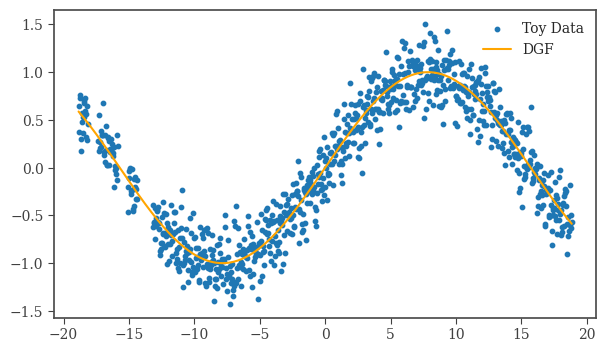

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(x_short, y_numpy, label="Toy Data", s=10)
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.legend()

plt.show()

## BNN with Laplace Approximation

A common problem with such Bayesian methods are intractable computations due to high computation costs. As such, it is common to use approximations. One possible approach are neural networks with Laplace Approximations, where the true posterior is approximated using a Gaussian distribution.

In [4]:
x = torch.from_numpy(x_short).to(torch.float32)
y = torch.from_numpy(y_numpy).to(torch.float32)

In [5]:
inv_prior = 0.009

bnn = BNNLA(x.shape[1], inv_prior)
optimizer = Adam(bnn.parameters(), lr=0.01, weight_decay=inv_prior)

for epoch in range(2_000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn(x)
    loss = bnn_loss(y_mean, y_log_var, y)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 0.2773
E100: Loss -1.0872
E200: Loss -1.1129
E300: Loss -1.1329
E400: Loss -1.1116
E500: Loss -1.1329
E600: Loss -1.1340
E700: Loss -1.1176
E800: Loss -0.9937
E900: Loss -1.1219
E1000: Loss -1.1325
E1100: Loss -1.1345
E1200: Loss -1.1048
E1300: Loss -1.1346
E1400: Loss -1.1295
E1500: Loss -1.1261
E1600: Loss -1.1348
E1700: Loss -1.1334
E1800: Loss -1.1347
E1900: Loss -1.0642


In [6]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

bnn.covariance(x_long)
y_pred, var_pred, total_var_pred = bnn.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

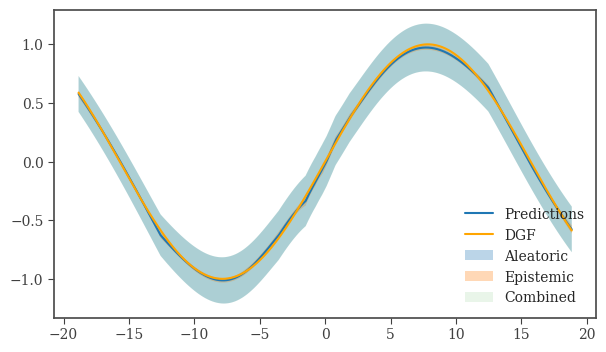

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, label="Aleatoric", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - epistemic_std, y_pred + epistemic_std, label="Epistemic", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, label="Combined", alpha=0.1)

ax.legend()

plt.show()

## Bayesian Neural Network with Variational Inference

A Bayesian Neural Network treats parameters as distributions instead of weights. The implementation used here stores the mean and variance of a normal distribution for each weight. Since full computation of the posterior is impossible, the implementation furthermore uses variational inference, where the posterior is approximated using a simpler distribution. Furthermore, since this relies on differentiating with respect to the parameters we sample from, the reparametrization trick is used.

In [8]:
bnn_vi = BNNVI(x.shape[1])
optimizer = Adam(bnn_vi.parameters(), lr=0.01)

for epoch in range(1000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn_vi(x)

    loss = negative_elbo(y_mean, y_log_var, y, bnn_vi.kl_divergence())
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 3.4537
E100: Loss 2.6270
E200: Loss 2.5599
E300: Loss 2.5838
E400: Loss 2.4439
E500: Loss 2.3597
E600: Loss 2.5799
E700: Loss 2.5562
E800: Loss 2.3805
E900: Loss 2.3259


In the inference step, several weights are sample using Monte Carlo sampling. From these samples, the mean, epistemic and aleatoric variances are predicted.

In [9]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_vi.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

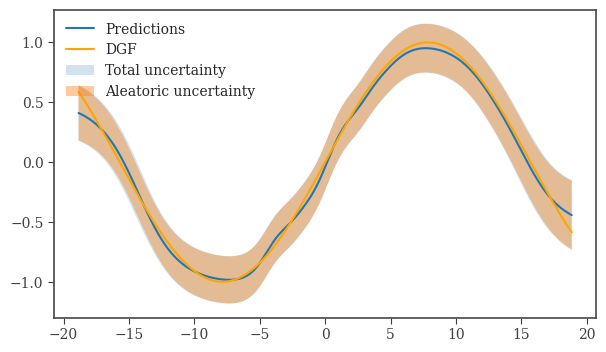

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4, label="Aleatoric uncertainty", )

ax.legend()

plt.show()

## MCMC for Neural Networks

There also exist MCMC methods for Bayesian Neural Networks. They work by saving weight samples every few training steps and averaging over model predictions of each stored weight sample to provide an estimate of the mean prediction. At the same time, this approach also gives an estimate of the epistemic uncertainty. The model used below is configured to predict the aleatoric uncertainty, too.

During training, random Gaussian noise is added. This is called Stochastic Gradient Langevin Dynamics.

In [81]:
num_samples, num_features = x.shape[0], x.shape[1]
random_permutation = torch.randperm(num_samples)

x = x[random_permutation]
y = y[random_permutation]

prior_variance = 1.0
bnn_mcmc = BNNMCMC(in_features=num_features, prior_variance=prior_variance)

batch_size = 64
steps = num_samples // batch_size
step_size = 2e-5
epochs = 500
burn_in_epochs = 450

for epoch in range(epochs):
    epoch_loss = 0
    for step in range(steps):
        x_batch = x[(step * batch_size):((step + 1) * batch_size)]
        y_batch = y[(step * batch_size):((step + 1) * batch_size)]
        bnn_mcmc.zero_grad()

        y_mean, y_log_var = bnn_mcmc(x_batch)

        nl_prior = bnn_mcmc.negative_log_prior()
        loss = sgdl_loss(y_mean, y_log_var, y_batch, nl_prior, num_samples)

        loss.backward()
        with torch.no_grad():
            for parameter in bnn_mcmc.parameters():
                noise = torch.randn_like(parameter)

                parameter.add_(
                    -0.5 * step_size * parameter.grad + step_size ** 0.5 * noise
                )
        epoch_loss += loss.item()
    if epoch % 10 == 0:
        print(f"E{epoch}: Loss {epoch_loss / steps}")

    if epoch > burn_in_epochs:
        bnn_mcmc.store_weight_sample()

E0: Loss 303.0443572998047
E10: Loss 53.31292002541678
E20: Loss -148.20385333469935
E30: Loss -178.53080912998743
E40: Loss -186.4053557259696
E50: Loss -191.2431013924735
E60: Loss -201.35273688180106
E70: Loss -212.15594754900252
E80: Loss -233.71141270228796
E90: Loss -238.35067531040735
E100: Loss -252.9066205705915
E110: Loss -268.86954825265065
E120: Loss -292.0935854230608
E130: Loss -313.2063435145787
E140: Loss -339.10996900285994
E150: Loss -364.2746113368443
E160: Loss -400.8163582938058
E170: Loss -415.1397792271205
E180: Loss -450.43778119768416
E190: Loss -466.5752214704241
E200: Loss -497.9152374267578
E210: Loss -506.99056352887834
E220: Loss -547.0532509940011
E230: Loss -564.4315490722656
E240: Loss -597.964348929269
E250: Loss -618.1217215401786
E260: Loss -666.2246660505023
E270: Loss -671.6869245256696
E280: Loss -668.0350058419364
E290: Loss -645.0958448137555
E300: Loss -671.6368953159878
E310: Loss -665.048076084682
E320: Loss -659.1426500592913
E330: Loss -686

In [85]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_mcmc.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

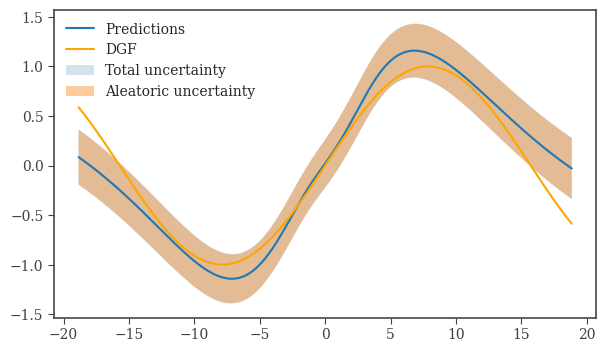

In [86]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4, label="Aleatoric uncertainty")

ax.legend()

plt.show()